In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('AB_NYC_2019.csv')

In [3]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
p_25, p_75 = np.percentile(data['price'], 25), np.percentile(data['price'], 75)

IQR = p_75 - p_25
cut_off = 1.5 * IQR
lower_bound = p_25 - cut_off
upper_bound = p_75 + cut_off

def classify(price):
    if price < lower_bound:
        return True
    elif price > upper_bound:
        return True
    else:
        return False

data['is_outlier'] = data['price'].apply(classify)

data = data[data['is_outlier'] == False]

Text(0, 0.5, 'counts')

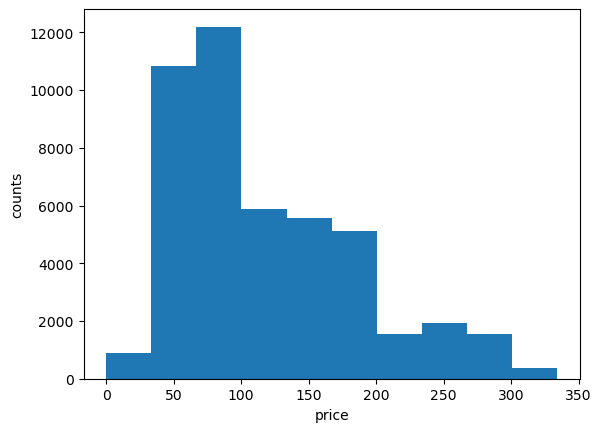

In [9]:
#Q1) Plot distribution of price

# counts, bins = np.histogram(data['price'])
# plt.hist(bins[:-1], bins, weights=counts)

plt.hist(data['price'])
plt.xlabel('price')
plt.ylabel('counts')

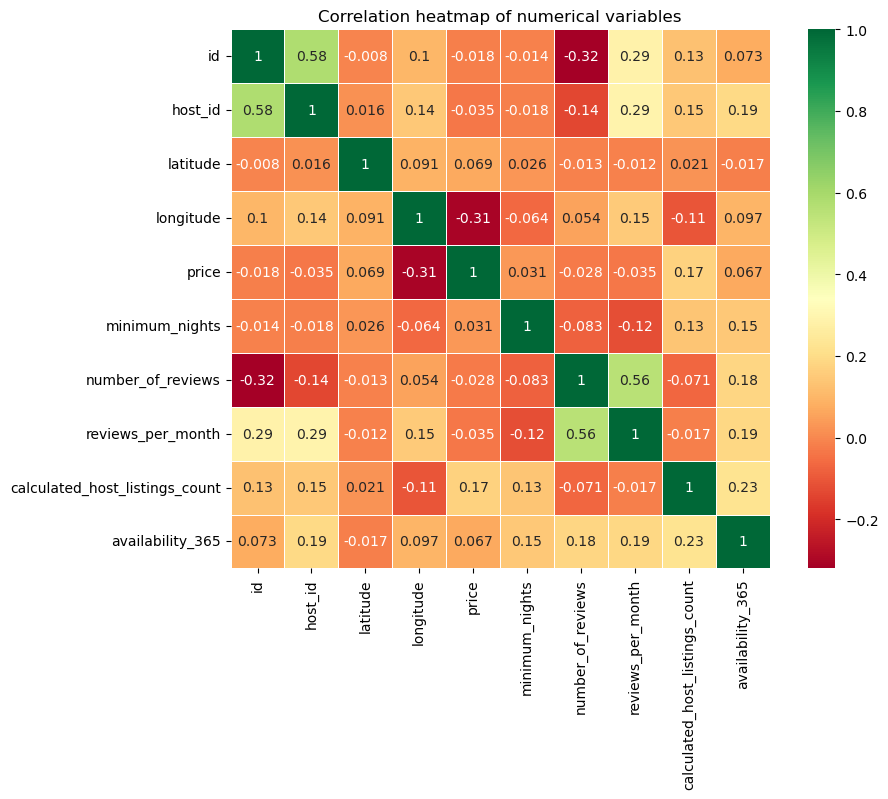

In [6]:
#Q2) Correlation heatmap of numeric columns

plt.figure(figsize=(10, 7))
title = 'Correlation heatmap of numerical variables'
numeric_data = data.select_dtypes(include=['number'])
sns.heatmap(numeric_data.corr(), annot=True, square=True, cmap='RdYlGn', linewidths=0.5)
plt.title(title)
plt.show()

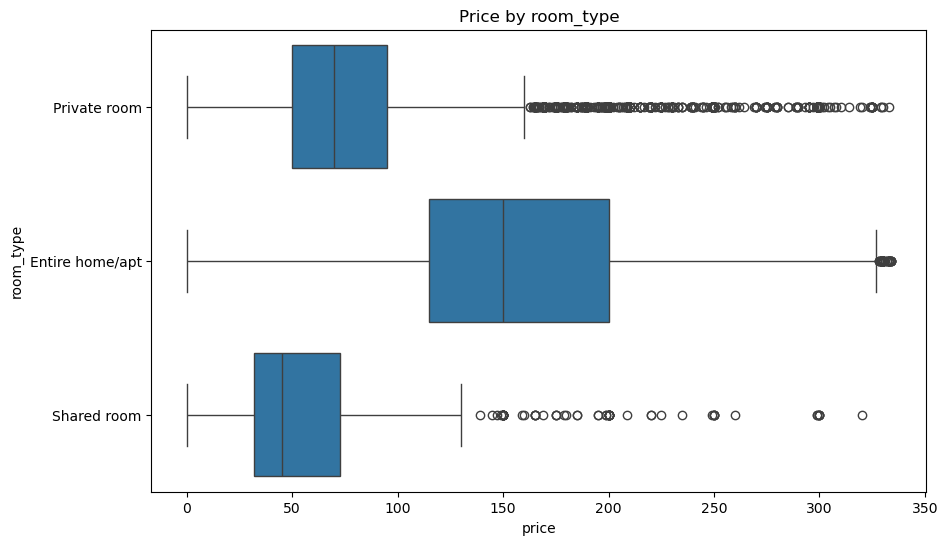

In [7]:
#Q3) Boxplot of price by room_type

title = 'Price by room_type'
plt.figure(figsize=(10, 6))
sns.boxplot(x='price', y='room_type', data=data).set_title(title)
plt.show()

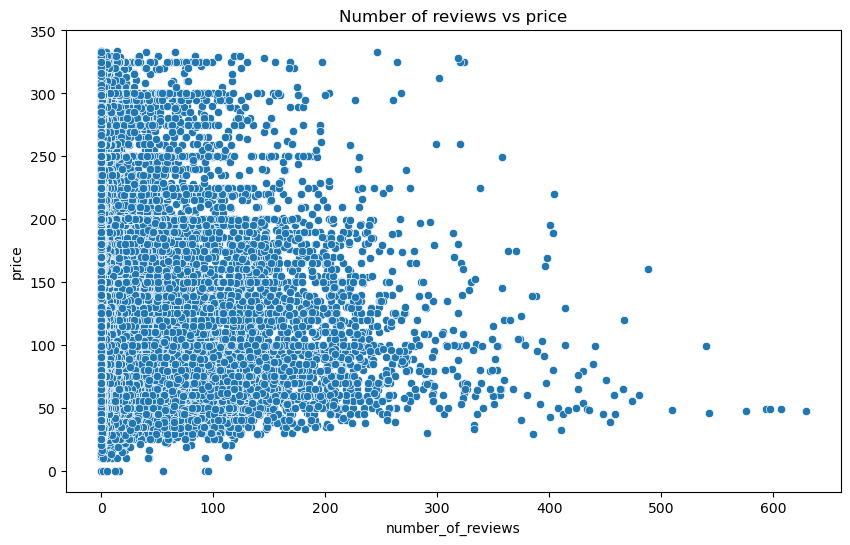

In [10]:
#Q4) Scatter: number_of_reviews vs price

title = 'Number of reviews vs price'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='number_of_reviews', y='price', data=data).set_title(title)
plt.show()

C:\Users\Sunny\AppData\Local\Temp\ipykernel_18260\1196007202.py:3: FutureWarning: The provided callable <function mean at 0x000002028F8BBA60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avg_price_per_neighbourhood = data.groupby(['neighbourhood_group']).agg({'price':np.mean}).reset_index()


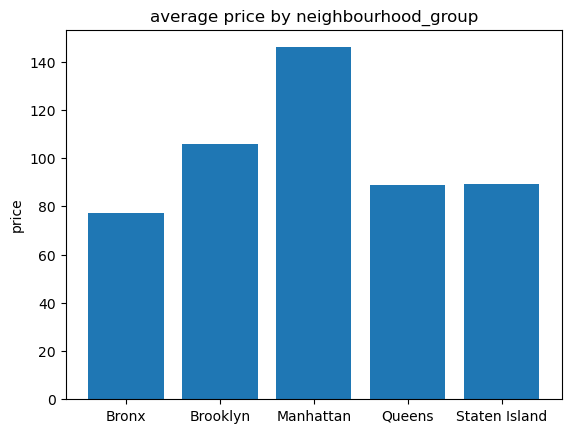

In [11]:
#Q5) Bar chart: average price by neighbourhood_group

avg_price_per_neighbourhood = data.groupby(['neighbourhood_group']).agg({'price':np.mean}).reset_index()

fig, ax = plt.subplots()

neighbourhoods = np.array(avg_price_per_neighbourhood.neighbourhood_group)
price = np.array(avg_price_per_neighbourhood.price)

ax.bar(neighbourhoods, price)

ax.set_ylabel('price')
ax.set_title('average price by neighbourhood_group')

plt.show()

In [ ]:
#Q6) Write 5 bullet-point observations from what you see
#1. As expected the histogram is skewed to the left, denoting people prefer lower price rooms.
#2.price seems to be most effected by host_listings_count
#3. As expected, private rooms seems to have many data points outside the range showing high priced rooms are rare and out of the range
#4. lower priced rooms seem to have higher number_of_reviews
#5. Manhanttan is the most expensive area to live in, followed by Brooklyn, Queens, Staten Island and Bronx (cheapest)